<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/07_ATH_Drawdown_Recovery_60M_SIP_JOURNEY_v3_POSITION_RISK_INDIAN_RUPEE_EQUAL_CASH_REDEPLOYMENT_LATEST_APPLE_TO_APPLE_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATH Drawdown + Recovery — 60-Month SIP Journey

This notebook implements the **ATH Drawdown + Recovery** portfolio journey using point-in-time monthly signals and next-month execution. It is designed to be self-contained, reproducible, auditable, and user-friendly.

### Core strategy
- Monthly screen: price at least the configured percentage below running ATH **and** at/above the 200-DMA.
- Rank eligible stocks by largest ATH drawdown, then conviction (`X-LC` before `H-LC`) and symbol.
- Use the prior month-end screen to make purchases on the next month's first trading-day open.
- Initial lump sum is added at the journey start; SIP is added monthly according to the setting below.
- Maximum MAX_HOLDINGS open positions;
- Position cap limits **new purchases/additions**; appreciated winners are not automatically sold at 7%.
- Positions above the hard concentration threshold are partially trimmed on the next month's first trading day toward the trim target.
- Sector cap limits **new purchases**; price appreciation may subsequently take a sector above the cap.
- Indian cash-equity quantities are **whole shares only**.
- Internal BUY/TRIM transactions are not investor cash flows for XIRR; only contributions and the terminal portfolio value are external cash flows.

> **Important:** Run this notebook from top to bottom in a fresh runtime. All parameters are defined inside the notebook; no previous notebook state is required.


## Apple-to-apple capital utilization policy

Both strategy notebooks use the same portfolio-construction utilization rule: **retain 5% of current portfolio value as strategic cash and deploy excess cash whenever qualifying opportunities have capacity**. A holding may be topped up while below the 5% stock cap; a new holding can only be opened while the portfolio is below the 20-stock maximum; new purchases remain subject to the 20% sector cap and whole-share execution. If the strategy has fewer eligible opportunities or integer-share/sector constraints prevent further deployment, the residual cash is retained. This isolates the stock-selection/exit logic as the strategy difference rather than allowing different cash-utilization mechanics. Cash utilization and turnover should be reported separately because high turnover can increase transaction costs even when capital is efficiently reused. citeturn0search0turn0search6

## 1. Dependencies

In [1]:
# If needed in Colab: %pip install yfinance pandas numpy matplotlib

from pathlib import Path
import hashlib
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("Ready.")


Ready.


## 2. User configuration

**This is the main cell you edit.** All strategy, capital, risk, execution, and data controls are defined here.

In [2]:
# ============================================================
# USER CONFIGURATION — edit this cell only for normal runs
# ============================================================

SIGNAL_FILE = Path("sample_data/signals.csv")

# Journey
START_DATE = "2023-04-01"
END_DATE = "2026-09-30"
EXPECTED_MONTHS = None          # Set to None to skip this check

# Capital
INITIAL_LUMP_SUM = 0            #10_000_000  # ₹1 crore
MONTHLY_SIP = 250_000           # ₹1 lakh
SIP_IN_FIRST_MONTH = True

# Strategy
ATH_DRAWDOWN_MIN = 0.20        # At least 20% below running ATH
DMA_WINDOW = 200
TOP_N = 20

# Position risk
MAX_HOLDINGS = 40             # Common maximum number of open stock positions; allows >20 holdings for capital utilization
MAX_POSITION_PCT = 0.05         # Maximum position size created by a new purchase/addition
POSITION_REVIEW_PCT = 0.12      # Review zone
POSITION_HARD_PCT = 0.15         # Hard concentration threshold
POSITION_TRIM_TARGET_PCT = 0.12  # Target after a hard-limit trim

# Sector risk
MAX_SECTOR_PCT = 0.20            # Restricts new purchases; appreciation may exceed it later

# Execution assumptions
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5

# Historical data
HISTORY_PERIOD = "max"

# If False, an existing holding cannot receive another BUY while it is already held.
ALLOW_REPEAT_BUYS = True

# Cash deployment policy — retain a small strategic reserve; redistribute excess cash.
TARGET_CASH_BUFFER_PCT = 0.05

# Current-screen diagnostic date. None = latest available price date.
AS_OF_DATE = None


## 3. Display helpers

In [3]:
def format_inr(value, decimals=0):
    if pd.isna(value):
        return "₹nan"
    value = float(value)
    sign = "-" if value < 0 else ""
    value = abs(value)
    number = f"{value:.{decimals}f}"
    integer, dot, fraction = number.partition(".")
    if len(integer) > 3:
        last3 = integer[-3:]
        rest = integer[:-3]
        groups = []
        while rest:
            groups.append(rest[-2:])
            rest = rest[:-2]
        integer = ",".join(reversed(groups)) + "," + last3
    return f"₹{sign}{integer}{dot}{fraction}"


## 4. Configuration validation and run summary

In [4]:
def validate_configuration():
    if pd.Timestamp(END_DATE) < pd.Timestamp(START_DATE):
        raise ValueError("END_DATE must be on or after START_DATE.")
    if INITIAL_LUMP_SUM < 0 or MONTHLY_SIP < 0:
        raise ValueError("INITIAL_LUMP_SUM and MONTHLY_SIP must be non-negative.")
    if not (0 < ATH_DRAWDOWN_MIN < 1):
        raise ValueError("ATH_DRAWDOWN_MIN must be between 0 and 1.")
    if DMA_WINDOW <= 0 or TOP_N <= 0 or MAX_HOLDINGS <= 0:
        raise ValueError("DMA_WINDOW, TOP_N and MAX_HOLDINGS must be positive integers.")
    if MAX_HOLDINGS > TOP_N:
        print("ℹ MAX_HOLDINGS is below TOP_N: the screen can consider more candidates than can be held simultaneously.")
    if not (0 < MAX_POSITION_PCT <= 1):
        raise ValueError("MAX_POSITION_PCT must be between 0 and 1.")
    if not (0 < POSITION_REVIEW_PCT <= 1):
        raise ValueError("POSITION_REVIEW_PCT must be between 0 and 1.")
    if not (0 < POSITION_TRIM_TARGET_PCT <= POSITION_HARD_PCT <= 1):
        raise ValueError("Require trim target <= hard threshold <= 100%.")
    if not (0 < MAX_SECTOR_PCT <= 1):
        raise ValueError("MAX_SECTOR_PCT must be between 0 and 1.")
    if TRANSACTION_COST_BPS < 0 or SLIPPAGE_BPS < 0:
        raise ValueError("Transaction cost and slippage cannot be negative.")
    if not SIGNAL_FILE.exists():
        raise FileNotFoundError(f"Signal file not found: {SIGNAL_FILE.resolve()}")

validate_configuration()

journey_months_check = pd.period_range(pd.Timestamp(START_DATE), pd.Timestamp(END_DATE), freq="M")
if EXPECTED_MONTHS is not None and len(journey_months_check) != EXPECTED_MONTHS:
    raise ValueError(
        f"START_DATE/END_DATE imply {len(journey_months_check)} calendar months, "
        f"but EXPECTED_MONTHS={EXPECTED_MONTHS}."
    )

print("RUN CONFIGURATION")
print("=" * 60)
print(f"Journey:                 {START_DATE} → {END_DATE} ({len(journey_months_check)} months)")
print(f"Initial lump sum:        {format_inr(INITIAL_LUMP_SUM)}")
print(f"Monthly SIP:             {format_inr(MONTHLY_SIP)}")
print(f"SIP in first month:      {SIP_IN_FIRST_MONTH}")
print(f"ATH drawdown minimum:    {ATH_DRAWDOWN_MIN:.1%}")
print(f"200-DMA window:          {DMA_WINDOW} trading days")
print(f"Top-N candidates:        {TOP_N}")
print(f"Max holdings:            {MAX_HOLDINGS}")
print(f"Position purchase cap:   {MAX_POSITION_PCT:.1%}")
print(f"Position review:         {POSITION_REVIEW_PCT:.1%}")
print(f"Position hard limit:     {POSITION_HARD_PCT:.1%}")
print(f"Trim target:             {POSITION_TRIM_TARGET_PCT:.1%}")
print(f"Sector purchase cap:     {MAX_SECTOR_PCT:.1%}")
print(f"Transaction cost:        {TRANSACTION_COST_BPS} bps")
print(f"Slippage:                {SLIPPAGE_BPS} bps")
print(f"Whole-share trading:     YES")
print(f"Repeat buys allowed:     {ALLOW_REPEAT_BUYS}")


ℹ MAX_HOLDINGS is below TOP_N: the screen can consider more candidates than can be held simultaneously.
RUN CONFIGURATION
Journey:                 2023-04-01 → 2026-09-30 (42 months)
Initial lump sum:        ₹0
Monthly SIP:             ₹2,50,000
SIP in first month:      True
ATH drawdown minimum:    20.0%
200-DMA window:          200 trading days
Top-N candidates:        20
Max holdings:            40
Position purchase cap:   5.0%
Position review:         12.0%
Position hard limit:     15.0%
Trim target:             12.0%
Sector purchase cap:     20.0%
Transaction cost:        10 bps
Slippage:                5 bps
Whole-share trading:     YES
Repeat buys allowed:     True


## 5. Load the strategy universe

In [5]:
signals = pd.read_csv(SIGNAL_FILE)
signals["Category"] = signals["Category"].fillna("Unknown").astype(str).str.strip()
signals.columns = [str(c).strip().lower() for c in signals.columns]

required = {"symbol", "conviction"}
missing = required - set(signals.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

signals["symbol"] = signals["symbol"].astype(str).str.strip().str.upper()
signals["conviction"] = signals["conviction"].astype(str).str.strip().str.upper()
signals = signals[signals["conviction"].isin(["X-LC", "H-LC"])].copy()
signals = signals.drop_duplicates("symbol", keep="first")
signals = signals[signals["symbol"] != "LTIM"].copy()

signals["conviction_rank"] = signals["conviction"].map({"X-LC": 1, "H-LC": 2})
signals["ticker"] = signals["symbol"] + ".NS"

print(f"Universe: {len(signals)} stocks")
display(signals[["symbol", "conviction"]].head(20))



Universe: 54 stocks


,symbol,conviction
0,TMPV,X-LC
1,TCS,X-LC
2,ITC,X-LC
3,INFY,X-LC
4,JIOFIN,X-LC
5,VBL,X-LC
6,BAJAJFINSV,X-LC
7,LTM,H-LC
8,DLF,H-LC
9,HDFCLIFE,X-LC


## 6. Download historical NSE data

In [6]:
# 4. Download real NSE data

tickers = signals["ticker"].tolist()
raw = yf.download(
    tickers=tickers,
    period=HISTORY_PERIOD,
    interval="1d",
    auto_adjust=True,
    progress=False,
    group_by="ticker",
    threads=True,
)

if raw.empty:
    raise RuntimeError("No data downloaded. Check internet access and ticker symbols.")

rows = []
if isinstance(raw.columns, pd.MultiIndex):
    levels = [raw.columns.get_level_values(i) for i in range(raw.columns.nlevels)]
    ticker_level = next(i for i, lv in enumerate(levels) if any(str(x) in tickers for x in lv))
    for ticker in tickers:
        if ticker not in set(raw.columns.get_level_values(ticker_level)):
            continue
        block = raw.xs(ticker, axis=1, level=ticker_level)
        block.columns = [str(c).title() for c in block.columns]
        if "Close" not in block.columns:
            continue
        block = block.reset_index()
        block = block.rename(columns={block.columns[0]: "date"})
        block["ticker"] = ticker
        rows.append(block[["date", "ticker", "Open", "High", "Low", "Close"]])
else:
    block = raw.reset_index()
    block = block.rename(columns={block.columns[0]: "date"})
    block["ticker"] = tickers[0]
    rows.append(block[["date", "ticker", "Open", "High", "Low", "Close"]])

prices = pd.concat(rows, ignore_index=True)
prices["date"] = pd.to_datetime(prices["date"]).dt.tz_localize(None)
prices["symbol"] = prices["ticker"].str.replace(".NS", "", regex=False)

for c in ["Open", "High", "Low", "Close"]:
    prices[c] = pd.to_numeric(prices[c], errors="coerce")

prices = prices.dropna(subset=["Close"]).sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"Rows: {len(prices):,}")
print(f"History: {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Stocks with data: {prices['symbol'].nunique()} / {len(signals)}")



Rows: 301,583
History: 1991-01-02 → 2026-09-22
Stocks with data: 54 / 54


## 7. Validate downloaded data and create a data fingerprint

In [7]:
import hashlib
required_price_cols = {"date", "symbol", "Open", "High", "Low", "Close"}
missing_price_cols = required_price_cols - set(prices.columns)
if missing_price_cols:
    raise ValueError(f"Missing price columns: {sorted(missing_price_cols)}")

if prices[["date", "symbol"]].duplicated().any():
    dup_count = int(prices[["date", "symbol"]].duplicated().sum())
    raise ValueError(f"Duplicate date/symbol price rows detected: {dup_count}")

if (prices["Close"] <= 0).any():
    raise ValueError("Non-positive Close prices detected.")

if prices["Open"].notna().sum() == 0:
    raise ValueError("No usable Open prices were downloaded; execution simulation cannot run.")

price_payload = pd.util.hash_pandas_object(
    prices[["date", "symbol", "Open", "High", "Low", "Close"]], index=True
).values.tobytes()
DATA_FINGERPRINT = hashlib.sha256(price_payload).hexdigest()[:16]

print(f"Rows:                 {len(prices):,}")
print(f"Date range:           {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Stocks with data:     {prices['symbol'].nunique()} / {len(signals)}")
print(f"Data fingerprint:     {DATA_FINGERPRINT}")


Rows:                 301,583
Date range:           1991-01-02 → 2026-09-22
Stocks with data:     54 / 54
Data fingerprint:     e6228c3464011420


## 8. Build historical indicators

In [8]:
# 5. Calculate running ATH, ATH drawdown and 200-DMA

prices["running_ath"] = prices.groupby("symbol")["Close"].cummax()
prices["ath_drawdown"] = prices["Close"] / prices["running_ath"] - 1
prices["dma_200"] = prices.groupby("symbol")["Close"].transform(
    lambda s: s.rolling(DMA_WINDOW, min_periods=DMA_WINDOW).mean()
)
prices["above_200dma"] = prices["Close"] >= prices["dma_200"]

prices = prices.merge(
    signals[["symbol", "conviction", "conviction_rank", "category"]],
    on="symbol",
    how="left"
)
prices = prices.rename(columns={"category": "Category"})


## 9. Select the current screening date

In [9]:
if AS_OF_DATE is None:
    as_of = prices["date"].max()
else:
    requested = pd.Timestamp(AS_OF_DATE)
    valid = prices.loc[prices["date"] <= requested, "date"]
    if valid.empty:
        raise ValueError("AS_OF_DATE is before the downloaded history.")
    as_of = valid.max()

snapshot = prices[prices["date"] == as_of].copy()
print(f"Screening date: {as_of.date()}")



Screening date: 2026-09-22


## 10. Apply the ATH Drawdown + Recovery screener

In [10]:
# 7. Apply ATH Drawdown + Recovery rules

snapshot["passes_ath_drawdown"] = snapshot["ath_drawdown"] <= -ATH_DRAWDOWN_MIN
snapshot["passes_recovery"] = snapshot["dma_200"].notna() & (snapshot["Close"] >= snapshot["dma_200"])
snapshot["eligible"] = snapshot["passes_ath_drawdown"] & snapshot["passes_recovery"]

eligible = snapshot[snapshot["eligible"]].copy()

# Largest drawdown first; X-LC receives priority when otherwise comparable.
eligible = eligible.sort_values(
    ["ath_drawdown", "conviction_rank", "symbol"],
    ascending=[True, True, True]
).reset_index(drop=True)
eligible["rank"] = np.arange(1, len(eligible) + 1)

top20 = eligible.head(TOP_N).copy()
top20["distance_from_ath_pct"] = -top20["ath_drawdown"]
top20["recovery_above_200dma_pct"] = top20["Close"] / top20["dma_200"] - 1

cols = [
    "rank", "symbol", "conviction", "Close", "running_ath",
    "distance_from_ath_pct", "dma_200", "recovery_above_200dma_pct"
]

print(f"Eligible stocks: {len(eligible)}")
print(f"Top {TOP_N}:")
display(top20[cols].style.format({
    "Close": lambda x: format_inr(x, 2),
    "running_ath": lambda x: format_inr(x, 2),
    "distance_from_ath_pct": "{:.1%}",
    "dma_200": lambda x: format_inr(x, 2),
    "recovery_above_200dma_pct": "{:.1%}",
}))



Eligible stocks: 3
Top 20:


,rank,symbol,conviction,Close,running_ath,distance_from_ath_pct,dma_200,recovery_above_200dma_pct
0,1,DLF,H-LC,₹665.35,"₹1,011.51",34.2%,₹621.90,7.0%
1,2,HYUNDAI,X-LC,"₹2,117.10","₹2,782.73",23.9%,"₹2,050.82",3.2%
2,3,BAJAJHLDNG,X-LC,"₹11,280.00","₹14,191.91",20.5%,"₹10,526.67",7.2%


## 11. Optional SIP allocation helper

In [11]:
# 11. Enter current holdings by market value (₹)
# Example:
# current_holdings = {"RELIANCE": 350000, "TCS": 420000}

current_holdings = {}
# You must define PORTFOLIO_VALUE if running this cell independently of the full journey.
# A sensible default for an initial run could be the INITIAL_LUMP_SUM.
PORTFOLIO_VALUE = INITIAL_LUMP_SUM

def suggested_sip_allocation(ranked, portfolio_value, monthly_sip, holdings, max_pct=MAX_POSITION_PCT):
    cap = portfolio_value * max_pct
    reserve = portfolio_value * TARGET_CASH_BUFFER_PCT
    remaining = max(0.0, float(monthly_sip) - reserve)
    ranked = ranked.copy()
    if ranked.empty:
        return pd.DataFrame(), float(monthly_sip)
    ranked["conviction_priority"] = ranked["conviction_rank"].fillna(99)
    ranked = ranked.sort_values(["conviction_priority", "rank", "symbol"], ascending=[True, True, True]).reset_index(drop=True)
    active = list(ranked.index)
    allocations = {i: 0.0 for i in active}
    while active and remaining > 1e-9:
        target_each = remaining / len(active)
        progress = False
        next_active = []
        for i in active:
            r = ranked.loc[i]
            current = float(holdings.get(r["symbol"], 0))
            room = max(0.0, cap - current)
            add = min(room, target_each)
            if add > 0:
                allocations[i] += add; remaining -= add; progress = True
            next_active.append(i)
        if not progress:
            break
        active = next_active
    out = []
    for i, r in ranked.iterrows():
        gross = allocations.get(i, 0.0)
        if gross <= 0: continue
        out.append({"rank": int(r["rank"]), "symbol": r["symbol"], "conviction": r["conviction"],
                    "current_value": float(holdings.get(r["symbol"], 0)), "position_cap": cap,
                    "room": max(0.0, cap - float(holdings.get(r["symbol"], 0))), "gross_SIP": gross,
                    "ATH_drawdown": r["ath_drawdown"], "above_200DMA": r["recovery_above_200dma_pct"]})
    result = pd.DataFrame(out)
    if not result.empty:
        drag = (TRANSACTION_COST_BPS + SLIPPAGE_BPS) / 10000
        result["estimated_net_investment"] = result["gross_SIP"] * (1 - drag)
    return result, remaining + reserve


allocation, unallocated = suggested_sip_allocation(
    top20, PORTFOLIO_VALUE, MONTHLY_SIP, current_holdings, MAX_POSITION_PCT
)

if allocation.empty:
    print("No qualifying allocation.")
else:
    display(allocation.style.format({
        "current_value": format_inr,
        "position_cap": format_inr,
        "room": format_inr,
        "gross_SIP": format_inr,
        "estimated_net_investment": format_inr,
        "ATH_drawdown": "{:.1%}",
        "above_200DMA": "{:.1%}",
    }))
    print(f"Unallocated SIP after position caps: {format_inr(unallocated)}")



No qualifying allocation.


## 12. Full-universe diagnostic

In [12]:
# 10. Full-universe diagnostic

view = snapshot[[
    "symbol", "conviction", "Close", "running_ath", "ath_drawdown",
    "dma_200", "above_200dma", "passes_ath_drawdown",
    "passes_recovery", "eligible"
]].copy()

view["reason"] = np.select(
    [
        ~view["passes_ath_drawdown"],
        ~view["passes_recovery"],
    ],
    [
        "Less than 20% below ATH",
        "Below 200-DMA or insufficient history",
    ],
    default="Eligible"
)

view = view.sort_values(["eligible", "ath_drawdown", "conviction_rank" if "conviction_rank" in view.columns else "symbol"])
display(view.style.format({
    "Close": lambda x: format_inr(x, 2),
    "running_ath": lambda x: format_inr(x, 2),
    "ath_drawdown": "{:.1%}",
    "dma_200": lambda x: format_inr(x, 2),
}))



,symbol,conviction,Close,running_ath,ath_drawdown,dma_200,above_200dma,passes_ath_drawdown,passes_recovery,eligible,reason
280544,TMPV,X-LC,₹300.75,"₹1,142.47",-73.7%,₹345.10,False,True,False,False,Below 200-DMA or insufficient history
263811,TCS,X-LC,"₹2,103.00","₹4,230.71",-50.3%,"₹2,504.61",False,True,False,False,Below 200-DMA or insufficient history
168050,INFY,X-LC,"₹1,024.40","₹1,901.08",-46.1%,"₹1,260.46",False,True,False,False,Below 200-DMA or insufficient history
41655,BAJAJFINSV,X-LC,"₹1,835.10","₹3,197.46",-42.6%,"₹1,893.27",False,True,False,False,Below 200-DMA or insufficient history
175762,ITC,X-LC,₹266.40,₹463.95,-42.6%,₹300.57,False,True,False,False,Below 200-DMA or insufficient history
198220,LTM,H-LC,"₹4,120.60","₹7,106.64",-42.0%,"₹4,666.72",False,True,False,False,Below 200-DMA or insufficient history
176528,JIOFIN,X-LC,₹230.60,₹386.44,-40.3%,₹250.88,False,True,False,False,Below 200-DMA or insufficient history
294995,VBL,X-LC,₹433.25,₹669.42,-35.3%,₹466.38,False,True,False,False,Below 200-DMA or insufficient history
153839,HINDUNILVR,X-LC,"₹1,944.30","₹2,909.86",-33.2%,"₹2,183.75",False,True,False,False,Below 200-DMA or insufficient history
122489,HCLTECH,X-LC,"₹1,261.00","₹1,853.42",-32.0%,"₹1,336.90",False,True,False,False,Below 200-DMA or insufficient history


## 13. Visual diagnostic

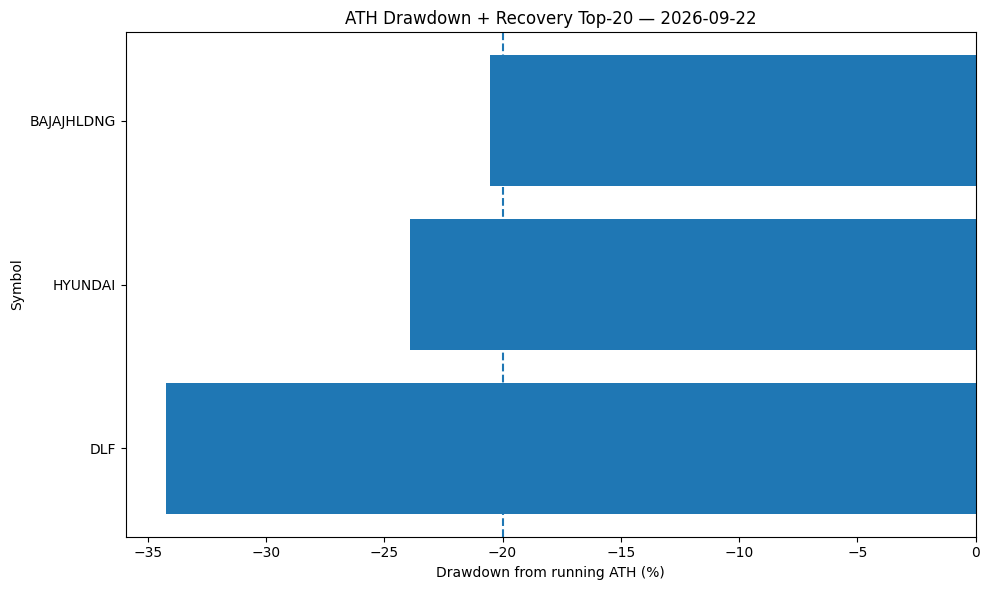

In [13]:
# 11. Visual diagnostic

if not top20.empty:
    chart = top20.sort_values("ath_drawdown")
    plt.figure(figsize=(10, 6))
    plt.barh(chart["symbol"], chart["ath_drawdown"] * 100)
    plt.axvline(-ATH_DRAWDOWN_MIN * 100, linestyle="--")
    plt.xlabel("Drawdown from running ATH (%)")
    plt.ylabel("Symbol")
    plt.title(f"ATH Drawdown + Recovery Top-{TOP_N} — {as_of.date()}")
    plt.tight_layout()
    plt.show()
else:
    print("No stocks currently satisfy both conditions.")



## 14. Export the current Top-N screen

In [14]:
# 14. Export this month's Top-N screen

stamp = as_of.strftime("%Y%m%d")
output_file = Path(f"ATH_Recovery_TopN_{stamp}.csv")

top20[[
    "rank", "symbol", "conviction", "Close", "running_ath",
    "ath_drawdown", "dma_200", "recovery_above_200dma_pct"
]].to_csv(output_file, index=False)

print(f"Saved: {output_file.resolve()}")



Saved: /content/ATH_Recovery_TopN_20260922.csv


## 15. Journey design and timing

## 15. Journey design and timing

The monthly journey is deliberately separated from the current-screen diagnostic. Purchases use the prior month-end screen and execute at the next month's first trading-day open.


## 16. Validate the journey window


In [15]:
# 17. Validate the journey window

start_ts = pd.Timestamp(START_DATE)
end_ts = pd.Timestamp(END_DATE)
if end_ts < start_ts:
    raise ValueError("END_DATE must be on or after START_DATE.")

journey_months = pd.period_range(start_ts, end_ts, freq="M")
n_months = len(journey_months)
if EXPECTED_MONTHS is not None and n_months != EXPECTED_MONTHS:
    raise ValueError(
        f"START_DATE/END_DATE imply {n_months} calendar months, "
        f"but EXPECTED_MONTHS={EXPECTED_MONTHS}. Change the dates or EXPECTED_MONTHS."
    )

print(f"Journey: {start_ts.date()} → {end_ts.date()}")
print(f"Calendar months: {n_months}")
print(f"Initial lump sum: {format_inr(INITIAL_LUMP_SUM)}")
print(f"Monthly SIP: {format_inr(MONTHLY_SIP)}")


Journey: 2023-04-01 → 2026-09-30
Calendar months: 42
Initial lump sum: ₹0
Monthly SIP: ₹2,50,000


## 17. Rebuild the historical signal series

In [16]:
# 19. Historical signal calculations

prices = prices.sort_values(["symbol", "date"]).copy()
prices["running_ath"] = prices.groupby("symbol")["Close"].cummax()
prices["ath_drawdown"] = prices["Close"] / prices["running_ath"] - 1
prices["dma_200"] = prices.groupby("symbol")["Close"].transform(
    lambda s: s.rolling(DMA_WINDOW, min_periods=DMA_WINDOW).mean()
)
prices["above_200dma"] = prices["Close"] >= prices["dma_200"]

# Daily month-end label.
prices["month"] = prices["date"].dt.to_period("M")

# Ensure static signal columns are present for the journey
# First, remove them if they already exist to avoid MergeError
cols_to_drop = ["conviction", "conviction_rank", "Category"]
prices = prices.drop(columns=[col for col in cols_to_drop if col in prices.columns])

prices = prices.merge(
    signals[["symbol", "conviction", "conviction_rank", "category"]],
    on="symbol",
    how="left"
)
prices = prices.rename(columns={"category": "Category"})

print(f"Usable price history: {prices['date'].min().date()} → {prices['date'].max().date()}")


Usable price history: 1991-01-02 → 2026-09-22


## 18. Point-in-time monthly screen helpers and journey calendar

In [17]:
# 20. Helper: monthly screen from a specified signal date

def screen_on_date(signal_date, top_n=TOP_N):
    """Return the strategy opportunity set known at signal_date."""
    d = pd.Timestamp(signal_date)
    snap = prices[prices["date"] == d].copy()
    if snap.empty:
        return pd.DataFrame()

    snap["passes_ath_drawdown"] = snap["ath_drawdown"] <= -ATH_DRAWDOWN_MIN
    snap["passes_recovery"] = snap["dma_200"].notna() & (snap["Close"] >= snap["dma_200"])
    eligible = snap[snap["passes_ath_drawdown"] & snap["passes_recovery"]].copy()

    # Canonical strategy selection: largest ATH drawdown first; X-LC is the
    # tie-break, then symbol. Allocation later always deploys to X-LC before H-LC.
    eligible = eligible.sort_values(
        ["ath_drawdown", "conviction_rank", "symbol"],
        ascending=[True, True, True]
    ).reset_index(drop=True)
    eligible["rank"] = np.arange(1, len(eligible) + 1)
    eligible["distance_from_ath_pct"] = -eligible["ath_drawdown"]
    eligible["recovery_above_200dma_pct"] = eligible["Close"] / eligible["dma_200"] - 1
    return eligible.head(top_n).copy()

def last_trading_day_on_or_before(d):
    d = pd.Timestamp(d)
    valid = prices.loc[prices["date"] <= d, "date"]
    return valid.max() if not valid.empty else pd.NaT

def first_trading_day_on_or_after(d):
    d = pd.Timestamp(d)
    valid = prices.loc[prices["date"] >= d, "date"]
    return valid.min() if not valid.empty else pd.NaT

def month_end_trading_day(period):
    end = period.end_time.normalize()
    return last_trading_day_on_or_before(end)

def month_first_trading_day(period):
    return first_trading_day_on_or_after(period.start_time.normalize())


In [18]:
month_rows = []
for p in journey_months:
    month_start = p.start_time.normalize()
    month_end = p.end_time.normalize()
    first_td = month_first_trading_day(p)
    month_end_td = month_end_trading_day(p)
    prior_signal_td = last_trading_day_on_or_before(month_start - pd.Timedelta(days=1))
    screen_td = month_end_trading_day(p)
    # Purchases made during this month are based on the prior month's month-end screen.
    purchase_screen = prior_signal_td
    month_rows.append({
        "month": str(p),
        "month_period": p,
        "month_start": month_start,
        "month_end": month_end,
        "first_trading_day": first_td,
        "month_end_trading_day": month_end_td,
        "purchase_screen_date": purchase_screen,
        "month_end_screen_date": screen_td,
    })

calendar = pd.DataFrame(month_rows)
calendar = calendar[calendar["first_trading_day"].notna() & calendar["month_end_trading_day"].notna()].copy()
display(calendar[["month","first_trading_day","purchase_screen_date","month_end_trading_day"]].head())


,month,first_trading_day,purchase_screen_date,month_end_trading_day
0,2023-04,2023-04-03,2023-03-31,2023-04-28
1,2023-05,2023-05-02,2023-04-28,2023-05-31
2,2023-06,2023-06-01,2023-05-31,2023-06-30
3,2023-07,2023-07-03,2023-06-30,2023-07-31
4,2023-08,2023-08-01,2023-07-31,2023-08-31


## 19. Portfolio engine

The engine follows one monthly state transition: contribution → scheduled trims → new purchases → month-end valuation. All BUY/TRIM quantities are integer shares.

In [19]:

COST_RATE = TRANSACTION_COST_BPS / 10000
SLIPPAGE_RATE = SLIPPAGE_BPS / 10000

close_lookup = prices.set_index(["date", "symbol"])["Close"]
open_lookup = prices.set_index(["date", "symbol"])["Open"]
category_lookup = prices.set_index(["date", "symbol"])["Category"]

cash = 0.0
shares = {}  # symbol -> integer shares held
cashflows = []
trade_rows = []
opportunity_rows = []
month_rows_out = []
audit_rows = []

# Month-end position weights above this threshold trigger a partial trim next month.
trim_queue = set()


def market_value_at(date):
    total = 0.0
    details = []
    for symbol, qty in shares.items():
        try:
            px = float(close_lookup.loc[(date, symbol)])
        except KeyError:
            px = np.nan
        if pd.notna(px):
            mv = qty * px
            total += mv
            details.append((symbol, qty, px, mv))
    return total, details


def xirr(cashflows_df):
    cf = cashflows_df.dropna(subset=["date", "amount"]).copy()
    if len(cf) < 2 or not (cf["amount"] > 0).any() or not (cf["amount"] < 0).any():
        return np.nan
    dates = pd.to_datetime(cf["date"])
    amounts = cf["amount"].astype(float).to_numpy()
    t0 = dates.iloc[0]
    years = np.array([(d - t0).days / 365.25 for d in dates])
    def npv(r):
        if r <= -0.999999:
            return np.inf
        return np.sum(amounts / ((1 + r) ** years))
    lo, hi = -0.9999, 10.0
    flo, fhi = npv(lo), npv(hi)
    if np.sign(flo) == np.sign(fhi):
        for new_hi in [25.0, 50.0, 100.0]:
            hi, fhi = new_hi, npv(new_hi)
            if np.sign(flo) != np.sign(fhi):
                break
    if np.sign(flo) == np.sign(fhi):
        return np.nan
    for _ in range(200):
        mid = (lo + hi) / 2
        fm = npv(mid)
        if abs(fm) < 1e-7:
            return mid
        if np.sign(fm) == np.sign(flo):
            lo, flo = mid, fm
        else:
            hi, fhi = mid, fm
    return (lo + hi) / 2

for month_number, (_, row) in enumerate(calendar.reset_index(drop=True).iterrows()):
    month = row["month"]
    first_td = row["first_trading_day"]
    month_end_td = row["month_end_trading_day"]
    purchase_screen_date = row["purchase_screen_date"]

    contribution = 0.0
    if month_number == 0:
        contribution += float(INITIAL_LUMP_SUM)
        if SIP_IN_FIRST_MONTH:
            contribution += float(MONTHLY_SIP)
    else:
        contribution += float(MONTHLY_SIP)
    cash += contribution

    if contribution > 0:
        cashflows.append({"date": first_td, "amount": -contribution, "type": "contribution"})

    opp = screen_on_date(purchase_screen_date, TOP_N) if pd.notna(purchase_screen_date) else pd.DataFrame()
    if not opp.empty:
        for _, r in opp.iterrows():
            opportunity_rows.append({
                "month": month,
                "screen_date": purchase_screen_date,
                "rank": int(r["rank"]),
                "symbol": r["symbol"],
                "conviction": r["conviction"],
                "category": r["Category"],
                "close_on_screen": float(r["Close"]),
                "ath_drawdown": float(r["ath_drawdown"]),
                "above_200dma_pct": float(r["recovery_above_200dma_pct"]),
            })

    # Value existing holdings at the first trading-day open.
    pre_mv = 0.0
    first_day_values = {}
    first_day_sectors = {}
    for symbol, qty in shares.items():
        try:
            px = float(open_lookup.loc[(first_td, symbol)])
            sector = str(category_lookup.loc[(first_td, symbol)])
        except KeyError:
            px, sector = np.nan, "Unknown"
        if pd.notna(px) and px > 0:
            mv = qty * px
            pre_mv += mv
            first_day_values[symbol] = mv
            first_day_sectors[sector] = first_day_sectors.get(sector, 0.0) + mv

    pre_equity = cash + pre_mv

    # ------------------------------------------------------------
    # Position-risk trims: only positions that breached the hard
    # concentration threshold at the PREVIOUS month-end are trimmed.
    # This keeps the 7% cap as an entry/addition cap while preventing
    # exceptional winners from becoming unbounded concentration risk.
    # ------------------------------------------------------------
    if month_number > 0 and trim_queue and pre_equity > 0:
        for symbol in sorted(trim_queue):
            qty_existing = int(shares.get(symbol, 0))
            if qty_existing <= 0 or symbol not in first_day_values:
                continue
            open_px = float(open_lookup.loc[(first_td, symbol)])
            current_mv = qty_existing * open_px
            target_mv = pre_equity * POSITION_TRIM_TARGET_PCT
            trim_value = max(0.0, current_mv - target_mv)
            if trim_value <= 1e-8:
                continue

            effective_px = open_px * (1 - SLIPPAGE_RATE)
            # Indian cash-equity trading uses whole shares only.
            qty_to_sell = min(qty_existing, int(np.floor(trim_value / effective_px + 1e-12)))
            gross_proceeds = qty_to_sell * effective_px
            transaction_cost = gross_proceeds * COST_RATE
            net_proceeds = gross_proceeds - transaction_cost
            if qty_to_sell <= 0 or net_proceeds <= 0:
                continue

            shares[symbol] = int(qty_existing - qty_to_sell)
            cash += net_proceeds
            trade_rows.append({
                "month": month,
                "trade_date": first_td,
                "screen_date": purchase_screen_date,
                "rank": np.nan,
                "symbol": symbol,
                "conviction": "Position Risk Trim",
                "category": str(category_lookup.loc[(first_td, symbol)]),
                "action": "TRIM",
                "shares_bought": -qty_to_sell,
                "open_price": open_px,
                "effective_price": effective_px,
                "gross_investment": -gross_proceeds,
                "transaction_cost": transaction_cost,
                "total_cash_out": -net_proceeds,
                "post_trade_cap": pre_equity * POSITION_HARD_PCT,
                "risk_threshold": POSITION_HARD_PCT,
                "trim_target": POSITION_TRIM_TARGET_PCT,
            })

            # Refresh first-day value after the trim so subsequent purchases
            # use the correct available cash and position size.
            first_day_values[symbol] = shares[symbol] * open_px

        trim_queue = set()

    # Recalculate equity/caps after any risk trims and before new purchases.
    pre_mv = sum(first_day_values.values())
    pre_equity = cash + pre_mv
    cap_value = pre_equity * MAX_POSITION_PCT
    sector_cap_value = pre_equity * MAX_SECTOR_PCT
    available = cash

    sector_values = {}
    for held_symbol, held_qty in shares.items():
        try:
            held_px = float(open_lookup.loc[(first_td, held_symbol)])
            held_sector = str(category_lookup.loc[(first_td, held_symbol)])
        except KeyError:
            continue
        if pd.notna(held_px) and held_px > 0:
            sector_values[held_sector] = sector_values.get(held_sector, 0.0) + held_qty * held_px

    if not opp.empty and available > 0:
        # X-LC is always preferred over H-LC for allocation, while the selected
        # opportunity set remains strategy-specific. Capital is allocated as
        # equally as possible across all candidates with remaining capacity.
        alloc_opp = opp.copy()
        alloc_opp["conviction_priority"] = alloc_opp["conviction_rank"].fillna(99)
        alloc_opp = alloc_opp.sort_values(["conviction_priority", "rank", "symbol"], ascending=[True, True, True]).reset_index(drop=True)
        active = list(alloc_opp["symbol"])
        meta = {r["symbol"]: r for _, r in alloc_opp.iterrows()}

        # Repeated passes redistribute excess cash created by stock/sector caps
        # or integer-share rounding. Both strategies use the same utilization
        # rule: retain only the 5% strategic cash buffer; deploy the remainder
        # whenever eligible opportunities have capacity. This is a capital-
        # utilization rule, not a change to the strategy's stock-selection logic.
        while active and cash > 0:
            reserve = pre_equity * TARGET_CASH_BUFFER_PCT
            deployable = max(0.0, cash - reserve)
            if deployable <= 1e-8:
                break
            target_each = deployable / len(active)
            progress = False
            next_active = []
            for symbol in active:
                if cash <= reserve + 1e-8:
                    break
                r = meta[symbol]
                if symbol not in set(signals["symbol"]):
                    continue
                qty_existing = int(shares.get(symbol, 0))
                # Common capital-utilization rule: existing qualifying holdings may
                # be topped up to the same 5% cap; new names require a free slot.
                if qty_existing <= 0 and len(shares) >= MAX_HOLDINGS:
                    continue
                if qty_existing > 0 and not ALLOW_REPEAT_BUYS:
                    continue
                if symbol not in open_lookup.index.get_level_values(1):
                    continue
                try:
                    open_px = float(open_lookup.loc[(first_td, symbol)])
                except KeyError:
                    continue
                if not np.isfinite(open_px) or open_px <= 0:
                    continue
                sector = str(r["Category"])
                existing_mv = qty_existing * open_px
                room = max(0.0, cap_value - existing_mv)
                current_sector_value = sector_values.get(sector, 0.0)
                sector_room = max(0.0, sector_cap_value - current_sector_value)
                gross_budget = min(room, sector_room, cash - reserve, target_each)
                if gross_budget <= 1e-8:
                    continue
                effective_px = open_px * (1 + SLIPPAGE_RATE)
                qty = int(np.floor(min(gross_budget / effective_px, (cash - reserve) / (effective_px * (1 + COST_RATE))) + 1e-12))
                consideration = qty * effective_px
                transaction_cost = consideration * COST_RATE
                total_cash = consideration + transaction_cost
                if qty <= 0 or total_cash <= 0:
                    # Keep it only if it may become buyable after redistribution.
                    next_active.append(symbol)
                    continue
                shares[symbol] = int(qty_existing + qty)
                sector_values[sector] = sector_values.get(sector, 0.0) + consideration
                cash -= total_cash
                available = cash
                progress = True
                trade_rows.append({
                    "month": month, "trade_date": first_td, "screen_date": purchase_screen_date,
                    "rank": int(r["rank"]), "symbol": symbol, "conviction": r["conviction"],
                    "category": sector, "action": "BUY", "shares_bought": qty, "open_price": open_px,
                    "effective_price": effective_px, "gross_investment": consideration,
                    "transaction_cost": transaction_cost, "total_cash_out": total_cash,
                    "post_trade_cap": cap_value, "risk_threshold": np.nan, "trim_target": np.nan,
                })
                next_active.append(symbol)
            if not progress:
                break
            active = next_active

    if not all(float(qty).is_integer() and qty >= 0 for qty in shares.values()):
        raise AssertionError(f"Integer-share invariant failed in {month}: {shares}")
    if cash < -1e-6:
        raise AssertionError(f"Negative cash invariant failed in {month}: {cash}")

    equity_value, holding_details = market_value_at(month_end_td)
    portfolio_value = cash + equity_value
    contributed = INITIAL_LUMP_SUM + MONTHLY_SIP * (month_number if not SIP_IN_FIRST_MONTH else month_number + 1)
    profit = portfolio_value - contributed
    profit_pct = profit / contributed if contributed else np.nan

    external_cf = [x for x in cashflows if x["type"] == "contribution"]
    cf = pd.DataFrame(external_cf + [{"date": month_end_td, "amount": portfolio_value, "type": "terminal_mark"}])
    current_xirr = xirr(cf)

    invested_pct = equity_value / portfolio_value if portfolio_value else 0.0
    cash_pct = cash / portfolio_value if portfolio_value else 0.0
    utilization_target_met = bool(cash_pct <= TARGET_CASH_BUFFER_PCT + 0.005)
    month_sector_values = {}
    month_stock_weights = {}
    for symbol, qty, px, mv in holding_details:
        try:
            sector = str(category_lookup.loc[(month_end_td, symbol)])
        except KeyError:
            sector = "Unknown"
        month_sector_values[sector] = month_sector_values.get(sector, 0.0) + mv
        month_stock_weights[symbol] = mv / portfolio_value if portfolio_value else 0.0

    max_sector_weight = (max(month_sector_values.values()) / portfolio_value) if month_sector_values and portfolio_value else 0.0
    max_sector_name = max(month_sector_values, key=month_sector_values.get) if month_sector_values else None
    max_stock_weight = max(month_stock_weights.values()) if month_stock_weights else 0.0
    max_stock_name = max(month_stock_weights, key=month_stock_weights.get) if month_stock_weights else None

    # Queue any hard-limit breaches observed at month-end for the next
    # month's first trading day. Review-zone positions are reported only.
    trim_queue = {s for s, w in month_stock_weights.items() if w > POSITION_HARD_PCT}

    cumulative_deployed = sum(t["total_cash_out"] for t in trade_rows if t["trade_date"] <= month_end_td and t["action"] == "BUY")
    cumulative_trim_proceeds = -sum(t["total_cash_out"] for t in trade_rows if t["trade_date"] <= month_end_td and t["action"] == "TRIM")
    month_rows_out.append({
        "month": month,
        "screen_date_for_month_end": row["month_end_screen_date"],
        "purchase_screen_date": purchase_screen_date,
        "first_trading_day": first_td,
        "month_end": month_end_td,
        "contribution_this_month": contribution,
        "cumulative_contributed": contributed,
        "gross_invested_value": equity_value,
        "cumulative_deployed": cumulative_deployed,
        "cumulative_trim_proceeds": cumulative_trim_proceeds,
        "cash_left": cash,
        "portfolio_value": portfolio_value,
        "invested_pct": invested_pct,
        "cash_pct": cash_pct,
        "utilization_target_met": utilization_target_met,
        "max_stock_weight": max_stock_weight,
        "max_stock": max_stock_name,
        "max_sector_weight": max_sector_weight,
        "max_sector": max_sector_name,
        "absolute_profit": profit,
        "absolute_profit_pct": profit_pct,
        "xirr": current_xirr,
        "num_holdings": len([x for x in holding_details if x[3] > 0]),
        "buy_events_this_month": sum(1 for t in trade_rows if t["month"] == month and t["action"] == "BUY"),
        "trim_events_this_month": sum(1 for t in trade_rows if t["month"] == month and t["action"] == "TRIM"),
        "eligible_opportunities": len(opp),
    })

    # Compact accounting/risk audit for this month.
    month_trades = [t for t in trade_rows if t["month"] == month]
    buy_cash = sum(t["total_cash_out"] for t in month_trades if t["action"] == "BUY")
    trim_cash = -sum(t["total_cash_out"] for t in month_trades if t["action"] == "TRIM")
    integer_ok = all(float(qty).is_integer() and qty >= 0 for qty in shares.values())
    cash_ok = cash >= -1e-6
    audit_rows.append({
        "month": month,
        "integer_shares_ok": integer_ok,
        "negative_cash_ok": cash_ok,
        "buy_cash": buy_cash,
        "trim_proceeds": trim_cash,
        "closing_cash": cash,
        "portfolio_value": portfolio_value,
        "buy_events": sum(1 for t in month_trades if t["action"] == "BUY"),
        "trim_events": sum(1 for t in month_trades if t["action"] == "TRIM"),
    })

monthly_journey = pd.DataFrame(month_rows_out)
trades = pd.DataFrame(trade_rows)
opportunities = pd.DataFrame(opportunity_rows)

print(f"Months simulated: {len(monthly_journey)}")
print(f"Buy events: {sum(trades['action'].eq('BUY')) if not trades.empty else 0:,}")
print(f"Trim events: {sum(trades['action'].eq('TRIM')) if not trades.empty else 0:,}")
print(f"Opportunity observations: {len(opportunities):,}")


# Final engine objects
audit = pd.DataFrame(audit_rows)


Months simulated: 42
Buy events: 144
Trim events: 0
Opportunity observations: 160


## 20. Portfolio validation and audit

In [20]:
def run_portfolio_audit():
    checks = []
    checks.append(("Configuration valid", True))
    checks.append(("Expected journey months", len(monthly_journey) == len(journey_months)))
    checks.append(("Integer shares throughout", bool(audit["integer_shares_ok"].all()) if not audit.empty else True))
    checks.append(("No negative cash", bool(audit["negative_cash_ok"].all()) if not audit.empty else True))
    checks.append(("No negative holdings", all(float(q) >= 0 for q in shares.values())))
    checks.append(("No fractional holdings", all(float(q).is_integer() for q in shares.values())))
    checks.append(("No look-ahead in purchase screens", bool((pd.to_datetime(calendar["purchase_screen_date"]) < pd.to_datetime(calendar["first_trading_day"])).all())) )
    checks.append(("Trade ledger present", True))

    audit_table = pd.DataFrame(checks, columns=["check", "passed"])
    display(audit_table.style.format({"passed": lambda x: "✓" if x else "✗"}))
    if not audit_table["passed"].all():
        failed = audit_table.loc[~audit_table["passed"], "check"].tolist()
        raise AssertionError(f"Portfolio audit failed: {failed}")
    print("Audit status: PASS")

run_portfolio_audit()
print(f"Data fingerprint: {DATA_FINGERPRINT}")


,check,passed
0,Configuration valid,✓
1,Expected journey months,✓
2,Integer shares throughout,✓
3,No negative cash,✓
4,No negative holdings,✓
5,No fractional holdings,✓
6,No look-ahead in purchase screens,✓
7,Trade ledger present,✓


Audit status: PASS
Data fingerprint: e6228c3464011420


## 21. Month-by-month journey results

In [21]:
# 25. Main month-by-month table

journey_view = monthly_journey.copy()
display(journey_view.style.format({
    "contribution_this_month": format_inr,
    "cumulative_contributed": format_inr,
    "cumulative_deployed": format_inr,
    "gross_invested_value": format_inr,
    "cash_left": format_inr,
    "portfolio_value": format_inr,
    "invested_pct": "{:.1%}",
    "cash_pct": "{:.1%}",
    "max_sector_weight": "{:.1%}",
    "absolute_profit": format_inr,
    "absolute_profit_pct": "{:.1%}",
    "xirr": "{:.1%}",
}))


,month,screen_date_for_month_end,purchase_screen_date,first_trading_day,month_end,contribution_this_month,cumulative_contributed,gross_invested_value,cumulative_deployed,cumulative_trim_proceeds,cash_left,portfolio_value,invested_pct,cash_pct,utilization_target_met,max_stock_weight,max_stock,max_sector_weight,max_sector,absolute_profit,absolute_profit_pct,xirr,num_holdings,buy_events_this_month,trim_events_this_month,eligible_opportunities
0,2023-04,2023-04-28 00:00:00,2023-03-31 00:00:00,2023-04-03 00:00:00,2023-04-28 00:00:00,"₹2,50,000","₹2,50,000","₹21,095","₹21,240",0,"₹2,28,760","₹2,49,855",8.4%,91.6%,False,0.050784,ZYDUSLIFE,5.1%,PHARMA,₹-145,-0.1%,-0.8%,2,2,0,3
1,2023-05,2023-05-31 00:00:00,2023-04-28 00:00:00,2023-05-02 00:00:00,2023-05-31 00:00:00,"₹2,50,000","₹5,00,000","₹1,24,672","₹1,24,110",0,"₹3,75,890","₹5,00,563",24.9%,75.1%,False,0.055058,DLF,5.5%,REALTY,₹563,0.1%,0.9%,6,5,0,5
2,2023-06,2023-06-30 00:00:00,2023-05-31 00:00:00,2023-06-01 00:00:00,2023-06-30 00:00:00,"₹2,50,000","₹7,50,000","₹3,22,232","₹3,00,927",0,"₹4,49,073","₹7,71,304",41.8%,58.2%,False,0.056085,ZYDUSLIFE,10.6%,PHARMA,"₹21,304",2.8%,19.0%,9,7,0,7
3,2023-07,2023-07-31 00:00:00,2023-06-30 00:00:00,2023-07-03 00:00:00,2023-07-31 00:00:00,"₹2,50,000","₹10,00,000","₹5,48,958","₹5,01,095",0,"₹4,98,905","₹10,47,864",52.4%,47.6%,False,0.064481,BSE,9.3%,PHARMA,"₹47,864",4.8%,25.7%,12,7,0,8
4,2023-08,2023-08-31 00:00:00,2023-07-31 00:00:00,2023-08-01 00:00:00,2023-08-31 00:00:00,"₹2,50,000","₹12,50,000","₹6,96,671","₹6,33,973",0,"₹6,16,027","₹13,12,699",53.1%,46.9%,False,0.068577,BSE,8.2%,PHARMA,"₹62,699",5.0%,21.8%,12,8,0,8
5,2023-09,2023-09-29 00:00:00,2023-08-31 00:00:00,2023-09-01 00:00:00,2023-09-29 00:00:00,"₹2,50,000","₹15,00,000","₹9,27,919","₹8,27,526",0,"₹6,72,474","₹16,00,393",58.0%,42.0%,False,0.068698,BSE,9.6%,IT,"₹1,00,393",6.7%,25.3%,13,9,0,9
6,2023-10,2023-10-31 00:00:00,2023-09-29 00:00:00,2023-10-03 00:00:00,2023-10-31 00:00:00,"₹2,50,000","₹17,50,000","₹10,69,967","₹9,46,369",0,"₹8,03,631","₹18,73,598",57.1%,42.9%,False,0.084227,BSE,9.4%,IT,"₹1,23,598",7.1%,22.7%,13,9,0,9
7,2023-11,2023-11-30 00:00:00,2023-10-31 00:00:00,2023-11-01 00:00:00,2023-11-30 00:00:00,"₹2,50,000","₹20,00,000","₹13,15,259","₹10,37,302",0,"₹9,62,698","₹22,77,957",57.7%,42.3%,False,0.092106,BSE,9.2%,MISC,"₹2,77,957",13.9%,41.2%,13,6,0,7
8,2023-12,2023-12-29 00:00:00,2023-11-30 00:00:00,2023-12-01 00:00:00,2023-12-29 00:00:00,"₹2,50,000","₹22,50,000","₹15,10,781","₹11,45,885",0,"₹11,04,115","₹26,14,896",57.8%,42.2%,False,0.071953,BSE,10.4%,IT,"₹3,64,896",16.2%,43.4%,13,7,0,7
9,2024-01,2024-01-31 00:00:00,2023-12-29 00:00:00,2024-01-01 00:00:00,2024-01-31 00:00:00,"₹2,50,000","₹25,00,000","₹15,75,292","₹11,94,494",0,"₹13,05,506","₹28,80,798",54.7%,45.3%,False,0.068322,BSE,9.2%,IT,"₹3,80,798",15.2%,35.6%,13,3,0,4


## 22. Opportunity history

In [22]:
# 27. Monthly opportunity table

if opportunities.empty:
    print("No qualifying opportunities in the journey window.")
else:
    display(opportunities.style.format({
        "close_on_screen": lambda x: format_inr(x, 2),
        "ath_drawdown": "{:.1%}",
        "above_200dma_pct": "{:.1%}",
    }))


,month,screen_date,rank,symbol,conviction,category,close_on_screen,ath_drawdown,above_200dma_pct
0,2023-04,2023-03-31 00:00:00,1,LTM,H-LC,IT,"₹4,526.62",-36.3%,5.0%
1,2023-04,2023-03-31 00:00:00,2,BOSCHLTD,X-LC,AUTO,"₹18,483.06",-25.1%,16.0%
2,2023-04,2023-03-31 00:00:00,3,ZYDUSLIFE,H-LC,PHARMA,₹479.86,-25.1%,20.0%
3,2023-05,2023-04-28 00:00:00,1,DLF,H-LC,REALTY,₹412.23,-59.2%,13.4%
4,2023-05,2023-04-28 00:00:00,2,HINDALCO,H-LC,METALS,₹425.45,-30.3%,2.5%
5,2023-05,2023-04-28 00:00:00,3,BOSCHLTD,X-LC,AUTO,"₹18,484.92",-25.1%,13.3%
6,2023-05,2023-04-28 00:00:00,4,APOLLOHOSP,X-LC,HEALTHCARE,"₹4,471.20",-21.0%,3.2%
7,2023-05,2023-04-28 00:00:00,5,ZYDUSLIFE,H-LC,PHARMA,₹507.54,-20.8%,22.8%
8,2023-06,2023-05-31 00:00:00,1,DLF,H-LC,REALTY,₹459.33,-54.6%,22.8%
9,2023-06,2023-05-31 00:00:00,2,BSE,X-LC,MISC,₹181.18,-43.5%,1.7%


## 23. Trade ledger

In [23]:
# 29. Trade ledger

if trades.empty:
    print("No trades were generated.")
else:
    display(trades.style.format({
        "shares_bought": "{:,.0f}",
        "open_price": lambda x: format_inr(x, 2),
        "effective_price": lambda x: format_inr(x, 2),
        "gross_investment": format_inr,
        "transaction_cost": format_inr,
        "total_cash_out": format_inr,
        "post_trade_cap": format_inr,
    }))


,month,trade_date,screen_date,rank,symbol,conviction,category,action,shares_bought,open_price,effective_price,gross_investment,transaction_cost,total_cash_out,post_trade_cap,risk_threshold,trim_target
0,2023-04,2023-04-03 00:00:00,2023-03-31 00:00:00,1,LTM,H-LC,IT,BUY,2,"₹4,526.95","₹4,529.21","₹9,058",₹9,"₹9,067","₹12,500",nan,nan
1,2023-04,2023-04-03 00:00:00,2023-03-31 00:00:00,3,ZYDUSLIFE,H-LC,PHARMA,BUY,25,₹486.16,₹486.40,"₹12,160",₹12,"₹12,172","₹12,500",nan,nan
2,2023-05,2023-05-02 00:00:00,2023-04-28 00:00:00,3,BOSCHLTD,X-LC,AUTO,BUY,1,"₹18,484.92","₹18,494.16","₹18,494",₹18,"₹18,513","₹24,994",nan,nan
3,2023-05,2023-05-02 00:00:00,2023-04-28 00:00:00,4,APOLLOHOSP,X-LC,HEALTHCARE,BUY,5,"₹4,487.09","₹4,489.34","₹22,447",₹22,"₹22,469","₹24,994",nan,nan
4,2023-05,2023-05-02 00:00:00,2023-04-28 00:00:00,1,DLF,H-LC,REALTY,BUY,60,₹412.91,₹413.11,"₹24,787",₹25,"₹24,812","₹24,994",nan,nan
5,2023-05,2023-05-02 00:00:00,2023-04-28 00:00:00,2,HINDALCO,H-LC,METALS,BUY,58,₹428.27,₹428.49,"₹24,852",₹25,"₹24,877","₹24,994",nan,nan
6,2023-05,2023-05-02 00:00:00,2023-04-28 00:00:00,5,ZYDUSLIFE,H-LC,PHARMA,BUY,24,₹507.54,₹507.79,"₹12,187",₹12,"₹12,199","₹24,994",nan,nan
7,2023-06,2023-06-01 00:00:00,2023-05-31 00:00:00,2,BSE,X-LC,MISC,BUY,206,₹181.80,₹181.89,"₹37,470",₹37,"₹37,507","₹37,557",nan,nan
8,2023-06,2023-06-01 00:00:00,2023-05-31 00:00:00,5,BOSCHLTD,X-LC,AUTO,BUY,1,"₹17,748.36","₹17,757.23","₹17,757",₹18,"₹17,775","₹37,557",nan,nan
9,2023-06,2023-06-01 00:00:00,2023-05-31 00:00:00,7,HDFCLIFE,X-LC,INSURANCE,BUY,64,₹585.78,₹586.08,"₹37,509",₹38,"₹37,546","₹37,557",nan,nan


## 24. Month-end holdings and compact portfolio snapshot

In [24]:
# 30. End-of-month portfolio holdings

holding_rows = []
for _, mr in monthly_journey.iterrows():
    d = mr["month_end"]
    for symbol, qty in shares.items():
        try:
            px = float(close_lookup.loc[(d, symbol)])
        except KeyError:
            continue
        # Reconstruct shares held through the trade ledger up to this month-end.
        if not trades.empty:
            q = trades.loc[trades["trade_date"] <= d].groupby("symbol")["shares_bought"].sum().get(symbol, 0.0)
        else:
            q = 0.0
        if q > 0:
            holding_rows.append({
                "month": mr["month"],
                "month_end": d,
                "symbol": symbol,
                "shares": q,
                "close": px,
                "market_value": q * px,
                "portfolio_weight": (q * px) / mr["portfolio_value"] if mr["portfolio_value"] else np.nan,
            })

monthly_holdings = pd.DataFrame(holding_rows)
if not monthly_holdings.empty:
    display(monthly_holdings.style.format({
        "shares": "{:,.0f}",
        "close": lambda x: format_inr(x, 2),
        "market_value": format_inr,
        "portfolio_weight": "{:.1%}",
    }))
else:
    print("No holdings to display.")


,month,month_end,symbol,shares,close,market_value,portfolio_weight
0,2023-04,2023-04-28 00:00:00,LTM,2,"₹4,203.07","₹8,406",3.4%
1,2023-04,2023-04-28 00:00:00,ZYDUSLIFE,25,₹507.54,"₹12,689",5.1%
2,2023-05,2023-05-31 00:00:00,LTM,2,"₹4,753.68","₹9,507",1.9%
3,2023-05,2023-05-31 00:00:00,ZYDUSLIFE,49,₹490.36,"₹24,028",4.8%
4,2023-05,2023-05-31 00:00:00,BOSCHLTD,1,"₹17,718.26","₹17,718",3.5%
5,2023-05,2023-05-31 00:00:00,APOLLOHOSP,5,"₹4,578.43","₹22,892",4.6%
6,2023-05,2023-05-31 00:00:00,DLF,60,₹459.33,"₹27,560",5.5%
7,2023-05,2023-05-31 00:00:00,HINDALCO,58,₹395.98,"₹22,967",4.6%
8,2023-06,2023-06-30 00:00:00,LTM,7,"₹4,942.75","₹34,599",4.5%
9,2023-06,2023-06-30 00:00:00,ZYDUSLIFE,76,₹569.19,"₹43,258",5.6%


In [25]:
# 36. Detailed month-end holdings snapshot

snapshot_rows = []
if not trades.empty:
    for _, mr in monthly_journey.iterrows():
        d = mr["month_end"]
        prior = trades[trades["trade_date"] <= d]
        for symbol, g in prior.groupby("symbol"):
            qty = g["shares_bought"].sum()
            buy_cash = g.loc[g["action"] == "BUY", "total_cash_out"].sum() if "action" in g.columns else g["total_cash_out"].sum()
            buy_shares = g.loc[g["action"] == "BUY", "shares_bought"].sum() if "action" in g.columns else g["shares_bought"].sum()
            avg_purchase_price = buy_cash / buy_shares if buy_shares else np.nan
            trim_proceeds = -g.loc[g["action"] == "TRIM", "total_cash_out"].sum() if "action" in g.columns else 0.0
            try:
                px = float(close_lookup.loc[(d, symbol)])
            except KeyError:
                continue
            try:
                sector = str(category_lookup.loc[(d, symbol)])
            except KeyError:
                sector = str(g["category"].iloc[-1]) if "category" in g.columns else "Unknown"
            mv = qty * px
            pnl = mv + trim_proceeds - buy_cash
            snapshot_rows.append({
                "month": mr["month"], "month_end": d, "symbol": symbol,
                "category": sector, "conviction": (g.loc[g["action"] == "BUY", "conviction"].iloc[-1] if "action" in g.columns and (g["action"] == "BUY").any() else g["conviction"].iloc[-1]),
                "shares": qty, "avg_purchase_price": avg_purchase_price, "month_end_price": px, "market_value": mv,
                "portfolio_weight": mv / mr["portfolio_value"] if mr["portfolio_value"] else np.nan,
                "cumulative_total_cash_out": buy_cash,
                "cumulative_trim_proceeds": trim_proceeds,
                "unrealized_pnl": pnl,
                "unrealized_pnl_pct": pnl / buy_cash if buy_cash else np.nan,
                "net_pnl_after_trims": pnl,
                "net_pnl_after_trims_pct": pnl / buy_cash if buy_cash else np.nan,
            })

monthly_holdings_snapshot = pd.DataFrame(snapshot_rows)
if monthly_holdings_snapshot.empty:
    print("No month-end holdings were generated.")
else:
    monthly_holdings_snapshot = monthly_holdings_snapshot.sort_values(["month_end","market_value"], ascending=[True,False]).reset_index(drop=True)
    display(monthly_holdings_snapshot.style.format({
        "shares":"{:,.0f}", "avg_purchase_price":lambda x: format_inr(x, 2), "month_end_price":lambda x: format_inr(x, 2), "market_value":format_inr,
        "portfolio_weight":"{:.1%}", "cumulative_total_cash_out":format_inr,
        "unrealized_pnl":format_inr, "unrealized_pnl_pct":"{:.1%}"
    }))


,month,month_end,symbol,category,conviction,shares,avg_purchase_price,month_end_price,market_value,portfolio_weight,cumulative_total_cash_out,cumulative_trim_proceeds,unrealized_pnl,unrealized_pnl_pct,net_pnl_after_trims,net_pnl_after_trims_pct
0,2023-04,2023-04-28 00:00:00,ZYDUSLIFE,PHARMA,H-LC,25,₹486.89,₹507.54,"₹12,689",5.1%,"₹12,172",-0.000000,₹516,4.2%,516.248063,0.042412
1,2023-04,2023-04-28 00:00:00,LTM,IT,H-LC,2,"₹4,533.74","₹4,203.07","₹8,406",3.4%,"₹9,067",-0.000000,₹-661,-7.3%,-661.336899,-0.072935
2,2023-05,2023-05-31 00:00:00,DLF,REALTY,H-LC,60,₹413.53,₹459.33,"₹27,560",5.5%,"₹24,812",-0.000000,"₹2,748",11.1%,2748.431500,0.110772
3,2023-05,2023-05-31 00:00:00,ZYDUSLIFE,PHARMA,H-LC,49,₹497.38,₹490.36,"₹24,028",4.8%,"₹24,372",-0.000000,₹-344,-1.4%,-343.930564,-0.014112
4,2023-05,2023-05-31 00:00:00,HINDALCO,METALS,H-LC,58,₹428.92,₹395.98,"₹22,967",4.6%,"₹24,877",-0.000000,"₹-1,910",-7.7%,-1910.168878,-0.076784
5,2023-05,2023-05-31 00:00:00,APOLLOHOSP,HEALTHCARE,X-LC,5,"₹4,493.83","₹4,578.43","₹22,892",4.6%,"₹22,469",-0.000000,₹423,1.9%,423.001079,0.018826
6,2023-05,2023-05-31 00:00:00,BOSCHLTD,AUTO,X-LC,1,"₹18,512.65","₹17,718.26","₹17,718",3.5%,"₹18,513",-0.000000,₹-794,-4.3%,-794.398228,-0.042911
7,2023-05,2023-05-31 00:00:00,LTM,IT,H-LC,2,"₹4,533.74","₹4,753.68","₹9,507",1.9%,"₹9,067",-0.000000,₹440,4.9%,439.871109,0.048511
8,2023-06,2023-06-30 00:00:00,ZYDUSLIFE,PHARMA,H-LC,76,₹495.15,₹569.19,"₹43,258",5.6%,"₹37,631",-0.000000,"₹5,627",15.0%,5627.303194,0.149539
9,2023-06,2023-06-30 00:00:00,HDFCLIFE,INSURANCE,X-LC,64,₹586.66,₹644.91,"₹41,274",5.4%,"₹37,546",-0.000000,"₹3,728",9.9%,3727.631054,0.099281


In [26]:
compact_rows = []
if not monthly_holdings_snapshot.empty:
    for month, g in monthly_holdings_snapshot.groupby("month", sort=False):
        g = g.sort_values("market_value", ascending=False)
        m = monthly_journey.loc[monthly_journey["month"] == month].iloc[0]
        holdings_text = " | ".join(f"{r.symbol} [{r.category}] {r.portfolio_weight:.1%} {format_inr(r.market_value)}" for r in g.itertuples())
        compact_rows.append({
            "month": month, "portfolio_value": m["portfolio_value"], "cash_left": m["cash_left"],
            "holdings_count": len(g), "max_stock_weight": g["portfolio_weight"].max(),
            "max_sector_weight": m["max_sector_weight"], "holdings": holdings_text
        })
compact_monthly_snapshot = pd.DataFrame(compact_rows)
display(compact_monthly_snapshot)


,month,portfolio_value,cash_left,holdings_count,max_stock_weight,max_sector_weight,holdings
0,2023-04,2.498549e+05,2.287603e+05,2,0.050784,0.050784,"ZYDUSLIFE [PHARMA] 5.1% ₹12,689 | LTM [IT] 3.4..."
1,2023-05,5.005628e+05,3.758904e+05,6,0.055058,0.055058,"DLF [REALTY] 5.5% ₹27,560 | ZYDUSLIFE [PHARMA]..."
2,2023-06,7.713042e+05,4.490727e+05,9,0.056085,0.106039,"ZYDUSLIFE [PHARMA] 5.6% ₹43,258 | HDFCLIFE [IN..."
3,2023-07,1.047864e+06,4.989055e+05,12,0.064481,0.093297,"BSE [MISC] 6.4% ₹67,567 | DLF [REALTY] 5.2% ₹5..."
4,2023-08,1.312699e+06,6.160272e+05,12,0.068577,0.081539,"BSE [MISC] 6.9% ₹90,021 | LICI [INSURANCE] 5.0..."
5,2023-09,1.600393e+06,6.724743e+05,13,0.068698,0.095766,"BSE [MISC] 6.9% ₹1,09,944 | HINDALCO [METALS] ..."
6,2023-10,1.873598e+06,8.036306e+05,13,0.084227,0.093895,"BSE [MISC] 8.4% ₹1,57,807 | DLF [REALTY] 5.2% ..."
7,2023-11,2.277957e+06,9.626982e+05,13,0.092106,0.092106,"BSE [MISC] 9.2% ₹2,09,813 | HINDALCO [METALS] ..."
8,2023-12,2.614896e+06,1.104115e+06,13,0.071953,0.104392,"BSE [MISC] 7.2% ₹1,88,149 | LICI [INSURANCE] 5..."
9,2024-01,2.880798e+06,1.305506e+06,13,0.068322,0.091802,"BSE [MISC] 6.8% ₹1,96,823 | LICI [INSURANCE] 6..."


## 25. Sector exposure by month

In [27]:
sector_rows = []
if not monthly_holdings_snapshot.empty:
    for (month, category), g in monthly_holdings_snapshot.groupby(["month","category"]):
        pv = monthly_journey.loc[monthly_journey["month"] == month, "portfolio_value"].iloc[0]
        sector_rows.append({
            "month":month,
            "category":category,
            "market_value":g["market_value"].sum(),
            "portfolio_weight":g["market_value"].sum()/pv if pv else np.nan,
            "stocks_in_sector":g["symbol"].nunique()
        })
sector_snapshot = pd.DataFrame(sector_rows).sort_values(["month","market_value"], ascending=[True,False])
if not sector_snapshot.empty:
    display(sector_snapshot.style.format({"market_value":format_inr,"portfolio_weight":"{:.1%}"}))


,month,category,market_value,portfolio_weight,stocks_in_sector
1,2023-04,PHARMA,"₹12,689",5.1%,1
0,2023-04,IT,"₹8,406",3.4%,1
7,2023-05,REALTY,"₹27,560",5.5%,1
6,2023-05,PHARMA,"₹24,028",4.8%,1
5,2023-05,METALS,"₹22,967",4.6%,1
3,2023-05,HEALTHCARE,"₹22,892",4.6%,1
2,2023-05,AUTO,"₹17,718",3.5%,1
4,2023-05,IT,"₹9,507",1.9%,1
14,2023-06,PHARMA,"₹81,789",10.6%,2
10,2023-06,INSURANCE,"₹41,274",5.4%,1


## 26. Portfolio journey charts

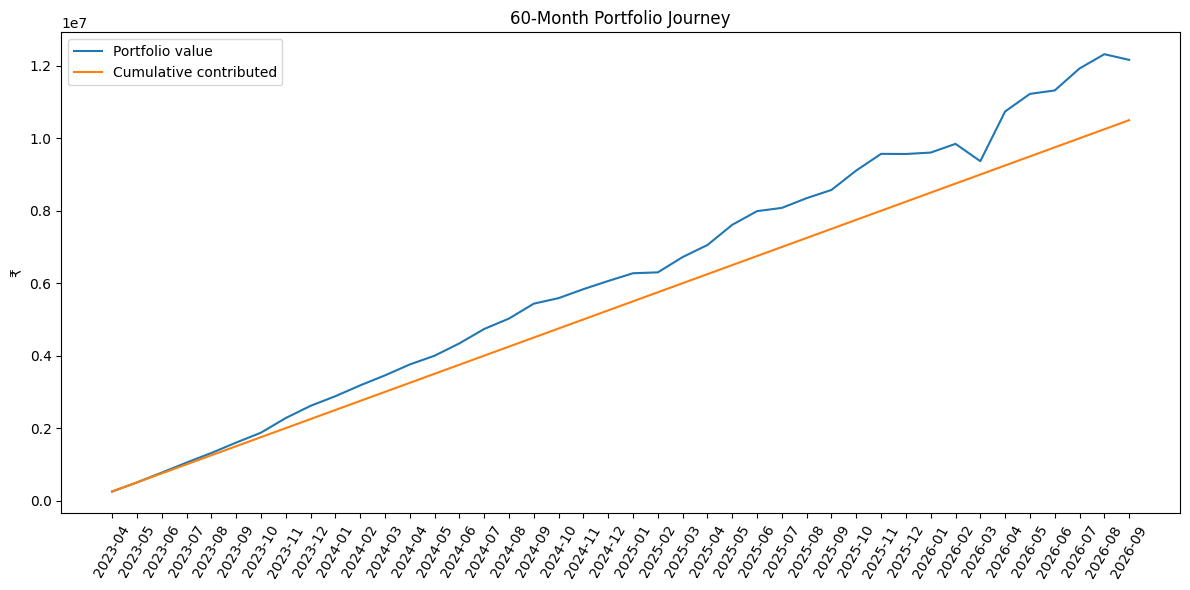

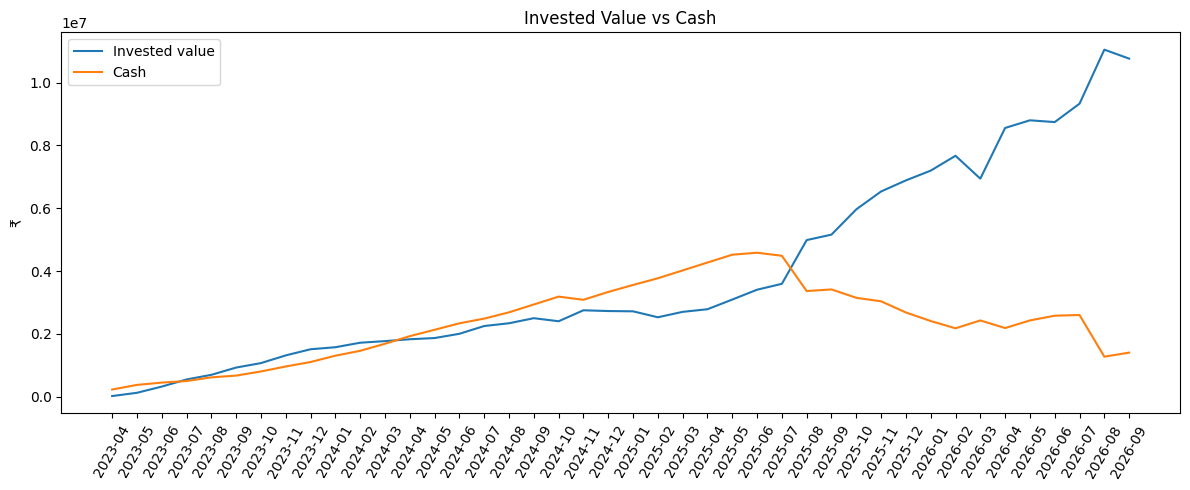

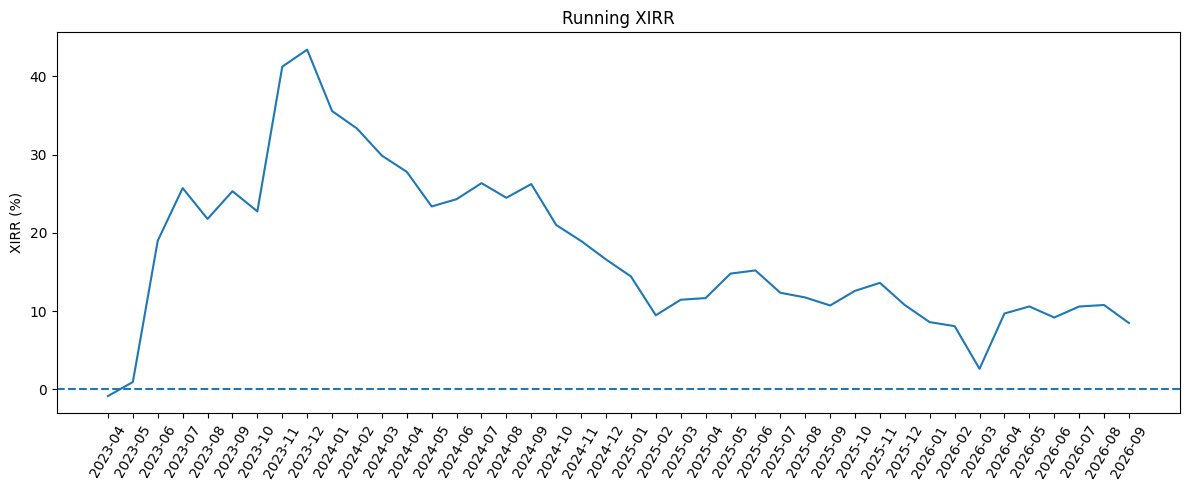

In [28]:
# 32. Portfolio journey charts

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_journey["month"], monthly_journey["portfolio_value"], label="Portfolio value")
ax.plot(monthly_journey["month"], monthly_journey["cumulative_contributed"], label="Cumulative contributed")
ax.set_title("60-Month Portfolio Journey")
ax.set_ylabel("₹")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_journey["month"], monthly_journey["gross_invested_value"], label="Invested value")
ax.plot(monthly_journey["month"], monthly_journey["cash_left"], label="Cash")
ax.set_title("Invested Value vs Cash")
ax.set_ylabel("₹")
ax.tick_params(axis="x", rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_journey["month"], monthly_journey["xirr"] * 100)
ax.axhline(0, linestyle="--")
ax.set_title("Running XIRR")
ax.set_ylabel("XIRR (%)")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


## 27. Final journey summary

In [29]:
# 33. Final journey summary

last = monthly_journey.iloc[-1]
print("FINAL JOURNEY SUMMARY")
print("=" * 60)
print(f"Journey: {START_DATE} → {END_DATE} ({n_months} months)")
print(f"Initial lump sum: {format_inr(INITIAL_LUMP_SUM)}")
print(f"Monthly SIP: {format_inr(MONTHLY_SIP)}")
print(f"Total contributed: {format_inr(last['cumulative_contributed'])}")
print(f"Cumulative deployed into purchases: {format_inr(last['cumulative_deployed'])}")
print(f"Cumulative trim proceeds: {format_inr(last['cumulative_trim_proceeds'])}")
print(f"Final invested value: {format_inr(last['gross_invested_value'])}")
print(f"Final cash: {format_inr(last['cash_left'])}")
print(f"Final portfolio value: {format_inr(last['portfolio_value'])}")
print(f"Absolute profit: {format_inr(last['absolute_profit'])}")
print(f"Absolute profit %: {last['absolute_profit_pct']:.2%}")
print(f"XIRR: {last['xirr']:.2%}")
print(f"Final invested %: {last['invested_pct']:.2%}")
print(f"Final cash %: {last['cash_pct']:.2%}")
print(f"Cash target <= {TARGET_CASH_BUFFER_PCT:.1%}: {'PASS' if last['utilization_target_met'] else 'NOT MET — check capacity/eligibility constraints'}")
print(f"Final holdings: {int(last['num_holdings'])}")
print(f"Max final sector weight: {last['max_sector_weight']:.2%}")
print(f"Max sector at final month: {last['max_sector']}")
print(f"Sector cap: {MAX_SECTOR_PCT:.2%}")
print(f"Stock purchase cap: {MAX_POSITION_PCT:.2%}")
print(f"Position review threshold: {POSITION_REVIEW_PCT:.2%}")
print(f"Position hard threshold: {POSITION_HARD_PCT:.2%}")
print(f"Position trim target: {POSITION_TRIM_TARGET_PCT:.2%}")
print(f"Total buy events: {sum(trades['action'].eq('BUY')) if not trades.empty else 0:,}")
print(f"Total trim events: {sum(trades['action'].eq('TRIM')) if not trades.empty else 0:,}")
print(f"Data fingerprint: {DATA_FINGERPRINT}")
print("Integer-share trading: PASS")


FINAL JOURNEY SUMMARY
Journey: 2023-04-01 → 2026-09-30 (42 months)
Initial lump sum: ₹0
Monthly SIP: ₹2,50,000
Total contributed: ₹1,05,00,000
Cumulative deployed into purchases: ₹90,96,260
Cumulative trim proceeds: ₹0
Final invested value: ₹1,07,60,934
Final cash: ₹14,03,740
Final portfolio value: ₹1,21,64,673
Absolute profit: ₹16,64,673
Absolute profit %: 15.85%
XIRR: 8.49%
Final invested %: 88.46%
Final cash %: 11.54%
Cash target <= 5.0%: NOT MET — check capacity/eligibility constraints
Final holdings: 23
Max final sector weight: 16.86%
Max sector at final month: AUTO
Sector cap: 20.00%
Stock purchase cap: 5.00%
Position review threshold: 12.00%
Position hard threshold: 15.00%
Position trim target: 12.00%
Total buy events: 144
Total trim events: 0
Data fingerprint: e6228c3464011420
Integer-share trading: PASS


## 28. Export all outputs

In [30]:
# 34. Export the journey tables

stamp = f"{pd.Timestamp(START_DATE):%Y%m%d}_{pd.Timestamp(END_DATE):%Y%m%d}"
monthly_file = Path(f"ATH_Recovery_Journey_Monthly_{stamp}.csv")
trade_file = Path(f"ATH_Recovery_Journey_Trades_{stamp}.csv")
opp_file = Path(f"ATH_Recovery_Journey_Opportunities_{stamp}.csv")
hold_file = Path(f"ATH_Recovery_Journey_Holdings_{stamp}.csv")

monthly_journey.to_csv(monthly_file, index=False)
trades.to_csv(trade_file, index=False)
opportunities.to_csv(opp_file, index=False)
monthly_holdings.to_csv(hold_file, index=False)

print("Exported:")
for f in [monthly_file, trade_file, opp_file, hold_file]:
    print(f" - {f.resolve()}")


Exported:
 - /content/ATH_Recovery_Journey_Monthly_20230401_20260930.csv
 - /content/ATH_Recovery_Journey_Trades_20230401_20260930.csv
 - /content/ATH_Recovery_Journey_Opportunities_20230401_20260930.csv
 - /content/ATH_Recovery_Journey_Holdings_20230401_20260930.csv


In [31]:
# 41. Export enhanced outputs

snapshot_file = Path(f"ATH_Recovery_Journey_Holdings_Snapshot_{stamp}.csv")
compact_file = Path(f"ATH_Recovery_Journey_Monthly_Compact_{stamp}.csv")
sector_file = Path(f"ATH_Recovery_Journey_Sector_Snapshot_{stamp}.csv")
monthly_holdings_snapshot.to_csv(snapshot_file,index=False)
compact_monthly_snapshot.to_csv(compact_file,index=False)
sector_snapshot.to_csv(sector_file,index=False)
print("Additional exports:")
for f in [snapshot_file,compact_file,sector_file]: print(f" - {f.resolve()}")


Additional exports:
 - /content/ATH_Recovery_Journey_Holdings_Snapshot_20230401_20260930.csv
 - /content/ATH_Recovery_Journey_Monthly_Compact_20230401_20260930.csv
 - /content/ATH_Recovery_Journey_Sector_Snapshot_20230401_20260930.csv
